# Lab 5 - Exploratory Data Analysis

In [1]:
% matplotlib inline

## General Instructions

In this course, Labs are the chance to applying concepts and methods discussed in the module.
They are a low stakes (pass/fail) opportunity for you to try your hand at *doing*.
Please make sure you follow the general Lab instructions, described in the Syllabus.
The summary is:

* Discussions should start as students work through the material, first Wednesday at the start of the new Module week. 
* Labs are due by Sunday. 
* Lab solutions are released Monday.  
* Post Self Evaluation and Lab to Lab Group on Blackboard and Lab to Module on Blackboard on Monday.

The last part is important because the Problem Sets will require you to perform the same or similar tasks without guidance.
Problem Sets are your opportunity to demonstrate that you understand how to apply the concepts and methods discussed in the relevant Modules and Labs.

## Specific Instructions

1.  For Blackboard submissions, if there are no accompanying files, you should submit *only* your notebook and it should be named using *only* your JHED id: fsmith79.ipynb for example if your JHED id were "fsmith79". If the assignment requires additional files, you should name the *folder/directory* your JHED id and put all items in that folder/directory, ZIP it up (only ZIP...no other compression), and submit it to Blackboard.

    * do **not** use absolute paths in your notebooks. All resources should located in the same directory as the rest of your assignments.
    * the directory **must** be named your JHED id and **only** your JHED id.
    * do **not** return files provided by us (data files, .py files)


2. Data Science is as much about what you write (communicating) as the code you execute (researching). In many places, you will be required to execute code and discuss both the purpose and the result. Additionally, Data Science is about reproducibility and transparency. This includes good communication with your team and possibly with yourself. Therefore, you must show **all** work.

3. Avail yourself of the Markdown/Codecell nature of the notebook. If you don't know about Markdown, look it up. Your notebooks should not look like ransom notes. Don't make everything bold. Clearly indicate what question you are answering.

4. Submit a cleanly executed notebook. The first code cell should say `In [1]` and each successive code cell should increase by 1 throughout the notebook.

## Exploratory Data Analysis

In this Module, we partitioned the problem of EDA using a taxonomy with the following characteristics:

* **Data Type**: Numerical or Categorical.
* **Number of Variables**: 1 or many.
* **Technique**: descriptive statistics, tables or charts.

we will skip "goal" for now.

And we came up with a general set of tools for analyzing data, not all of them applicable to all the cases:

* Descriptive Statistics
* Frequency Table (absolute and relative)
* Histograms
* Boxplots Plot
* Bar chart
* Dot chart
* Heat map
* Scatter Plot

This does not exhaust all the chart types, though. We also have the following basic chart types that we talked about in the Visualization Module:

* Points
* Lines
* Lines and points

The goal for this lab is to get you acquainted with most of these tools by analyzing a real data set. You *must* follow the framework discussed in the Module for a *methodical* EDA:

1. Single Variable Exploration.
2. Exploration of Pairwise Relationships.

Each and every analysis (of a single variable or a pair of variables) should follow the general pattern of discuss/code/discuss. If you need examples for EDA, look at the Example in *Fundamentals*. 

In order to guide the EDA, you can take the following as the main question:

> What are the factors influencing charges?

Using that problem as a guide, explore 5 pairwise relationships. Because you have a question, you should *not* use correlations as a *guide* to exploration (however, correlation coefficients are still reasonable descriptive statistics for two numeric variables).

As you explore those pairings, questions will arise, "I wonder if...." or "I wonder about...". Make note of them. **Do not get distracted**. As a rough guide, you should get three (3) questions out of every single or pairwise exploration. As a result, you should have at least 15 of them when you're done (plus all the questions you generated looking at each variable individually!).

Pick five (5) of *those* questions and answer them.

And for each case, try different visualizations. What does a histogram tell you that a box-and-whiskers plot does not and vice versa? What about different bin sizes? And the most important bit: you must write something for every single chart you produce. 

The emphasis here is on *science*.

At every juncture, you must say:

1. **Why am I trying this?** "I'm going to look at this data using a box and whiskers plot to explore its general shape." "I am trying more bins to see if the histogram reveals any interesting characteristics."
2. **Do it.**
3. **What did I learn?** "Although I know the data is generated from a normal distribution, it doesn't look normally distributed. The sample mean is X while the true mean is Y."

BTW, do not literally say "Why am I doing this?"...these questions are just *prompts* or *scaffolding*.

For now, you shouldn't just "change" anything. Let's say you start with 10 bins in your histogram. You decide you want to see what happens with 20. **Do not just change the value to 20**. Instead, make a new histogram with 20 bins, documenting why you thought 20 bins might be better, what you hoped to see, and then what you saw as a result of doing it.

(Believe me, there will be a time when a boss says "did you try 10 bins?" and you'll say "yes" but you won't remember what it looked like or they'll want to see it and you'll have to do it all again anyway. Your notebook is a documentation of *everything* you tried.)

Be inventive and creative.

In [2]:
import numpy as np
import random as py_random
import numpy.random as np_random
import time
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

sns.set(style="whitegrid")

# Answer

Use this link to get the data:

```
insurance = pd.read_csv("https://raw.githubusercontent.com/fundamentals-of-data-science/datasets/master/insurance.csv")
```

In [3]:
insurance = pd.read_csv("https://raw.githubusercontent.com/fundamentals-of-data-science/datasets/master/insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


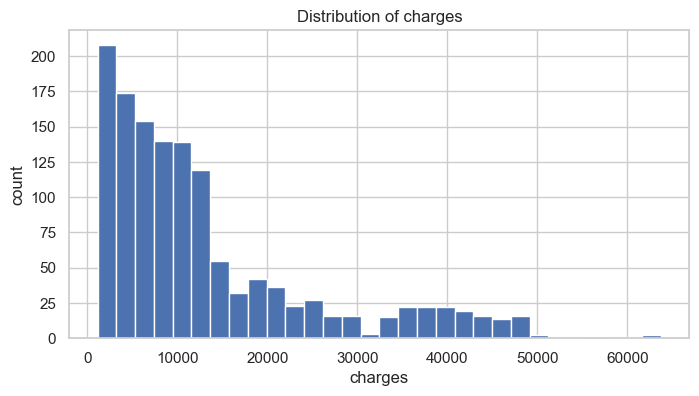

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64
skew: 1.52


In [6]:
plt.figure(figsize=(8,4))
plt.hist(insurance["charges"], bins=30)
plt.xlabel("charges")
plt.ylabel("count")
plt.title("Distribution of charges")
plt.show()

print(insurance["charges"].describe())
print("skew:", round(insurance["charges"].skew(), 2))

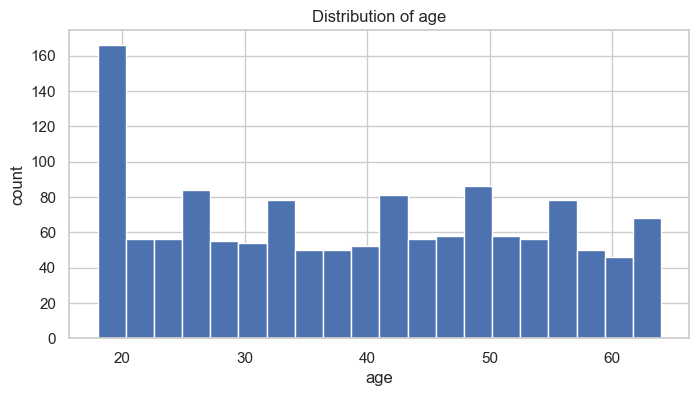

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64


: 

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(insurance["age"], bins=20)
plt.xlabel("age")
plt.ylabel("count")
plt.title("Distribution of age")
plt.show()

print(insurance["age"].describe())